# Process and plot IRM-DCD and Hysteresis Data 
Author: Peter Selkin  
Last Updated 8/13/2025  
  
This notebook analyzes and plots data from hysteresis, isothermal remanent magnetization (IRM) and DC demagnetization (DCD) experiments from Princeton Measurements Corp. VSMs like the one at Western Washington University. This now includes code to process __both__ `.irmdcd/dcd` files and `.hysu` files. 

This notebook makes extensive use of the [`pandas`](https://pandas.pydata.org/docs/getting_started/overview.html) package, especially the [`DataFrame`](https://pandas.pydata.org/docs/getting_started/intro_tutorials/02_read_write.html) data type. This is similar to the `data.frame` or _tibble_ (`tbl_df`) types in R. You might want to read up on DataFrames in order to get the most out of this notebook. You might also want to check out the first few chapters of Jake Vanderplas's [Python Data Science Handbook](https://github.com/jakevdp/PythonDataScienceHandbook).

This notebook also makes extensive use of Vanderplas's [`altair`](https://altair-viz.github.io/) package for plotting, somewhat analogous to `ggplot` in R. A large number of examples are available at <https://altair-viz.github.io/gallery/index.html>. These might give you some ideas about how to plot data from your experiments so you can communicate your interpretations. 

Understanding the background of hysteresis and IRM is a little more difficult. The first chapter of Maher and Thompson's _Quaternary Environments and Magnetism_ is a good place to start. You might also check out Bruce Moskowitz's [_Hitchhiker's Guide to Rock Magnetism_](https://www.magneticmicrosphere.com/resources/hitchhiker_guide_to_magnetism.pdf) - it's more a collection of notes than a reading, but it might illuminate some abstract points that you encountered in Maher and Thompson. A lot of the hysteresis processing comes from a 2009 _G-Cubed_ paper by Jackson and Solheid (["On the quantitative analysis and evaluation of magnetic hysteresis data"](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2009GC002932)). The classic references on IRM acquisition and coercivity spectra are Robertson and France (1994), "Discrimination of remanence-carrying minerals in mixtures,
using isothermal remanent magnetisation acquisition curves" and Egli (2004), "Characterization of Individual Rock Magnetic Components by Analysis of Remanence Curves, 1. Unmixing Natural Sediments", both available on our lab's Teams drive. We usually use [MaxUnmix](https://shinyapps.carleton.edu/max-unmix/) to process these data; the `.hm` files we produce are designed to be used directly in MaxUnmix.

In [1]:
# Import packages: These are like "plugins" that provide specialized functions that aren't part of standard Python.
#
# Most of the packages used are installed with Anaconda. 
#
# I wrote Hysttools for managing hysteresis and IRM/DCD data. It is included with this notebook if you 
# downloaded it from Github. It relies on some functions from PmagPy, which you should have installed if
# you followed the setup directions on Github.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import scipy.interpolate as spi
import scipy.optimize as spo
import scipy.stats as sps
import altair as alt
import hysttools as ht
from pathlib import Path
from datetime import date

In [2]:
# Enable Altair Data Server: Altair is a data visualization package (analogous to ggplot in R). 
# Data Server allows it to plot LOTS of data on a graph.
from altair_data_server import data_server
alt.data_transformers.enable('data_server')

DataTransformerRegistry.enable('data_server')

## Read Data

In [3]:
# Find the data files and identify the names of the samples in them.

# The following variables tell Python where to look for the files.
#repo=git.Repo('.', search_parent_directories=True)
path_root = Path(os.getcwd()).parent    # The "root" or base folder with the info for this project is one folder "up" 
                                        # from the folder where this notebook is. 
data_folder = path_root / 'data'
processed_folder = data_folder / 'processed'
vsm_folder = data_folder / 'raw'/'vsm'
image_folder = data_folder / 'images'

irmdcd_pattern = re.compile('.*dcd$') # This is the suffix for a dcd (.dcd) or irm-dcd (.irmdcd) file
irmdcd_list = list(filter(irmdcd_pattern.match,os.listdir(vsm_folder))) # Make a list of all the dcd/irm-dcd files

specimens=pd.read_excel(data_folder/'raw'/'metadata.xlsx')    # This file contains a list of files and the associated 
                                                              # sample names and info
sites=pd.read_excel(data_folder/'raw'/'sites.xlsx')
specimens=pd.merge(specimens,sites,on='site',how='left')      # Merge the sites with the specimens file: for each specimen, 
                                                              # add the corresponding info from the sites file based on which 
                                                              # site is listed in the "site" column 

irmdcd_pattern = re.compile('.*dcd$') # This is the suffix for a dcd (.dcd) or irm-dcd (.irmdcd) file
irmdcd_list = list(filter(irmdcd_pattern.match,os.listdir(vsm_folder))) # Make a list of all the dcd/irm-dcd files
yes_irmdcd = specimens['irmdcd_file'].isin(irmdcd_list) # How many of the rows in the specimens data frame have files in the raw folder?
no_irmdcd = ~specimens['irmdcd_file'].isin(irmdcd_list) # How many of the rows in the specimens data frame don't have files in the raw folder?
print("\n{} IRMDCD files to process.".format(np.shape(irmdcd_list)[0]))
print(f"Matches:{sum(yes_irmdcd)}\nNon-Matches:{sum(no_irmdcd)}")

hysu_pattern = re.compile('.*hysu$') # This is the suffix for a hysteresis file
hysu_list = list(filter(hysu_pattern.match,os.listdir(vsm_folder))) # Make a list of all the hysteresis files
yes_hysu = specimens['hysu_file'].isin(hysu_list) # How many of the rows in the specimens data frame have files in the raw folder?
no_hysu = ~specimens['hysu_file'].isin(hysu_list) # How many of the rows in the specimens data frame don't have files in the raw folder?
print("\n{} HYSU files to process.".format(np.shape(hysu_list)[0]))
print(f"Matches:{sum(yes_hysu)}\nNon-Matches:{sum(no_hysu)}")

# Show the list of specimens (i.e. merged metadata and sites files)
display(specimens)


40 IRMDCD files to process.
Matches:40
Non-Matches:0

38 HYSU files to process.
Matches:40
Non-Matches:0


,irmdcd_file,hysu_file,subsample,sample,site,season,year,sample_type,watershed,unit,grain_size,mass,Notes,site_name,lat,lon
0,2022CB0101.irmdcd,2022CB0101.hysu,2022-cb-01-01,2022-cb-01,cb01,NaN,2022.0,marine,bay,NaN,NaN,0.2951,NaN,Commencement Bay,NaN,NaN
1,2022CB0103.irmdcd,2022CB0103.hysu,2022-cb-01-03,2022-cb-01,cb01,NaN,2022.0,marine,bay,NaN,NaN,0.2813,NaN,Commencement Bay,NaN,NaN
2,2022EG0102.irmdcd,2022EG0102.hysu,2022-eg-01-02,2022-eg-01,eg01,su,2022.0,headwaters,white,NaN,NaN,0.3726,NaN,Emmons Glacier,NaN,NaN
3,2022EG0103-2.irmdcd,2022EG0103.hysu,2022-eg-01-03,2022-eg-01,eg01,su,2022.0,headwaters,white,NaN,NaN,0.2813,NaN,Emmons Glacier,NaN,NaN
4,2022EG0103.irmdcd,2022EG0103.hysu,2022-eg-01-03,2022-eg-01,eg01,su,2022.0,headwaters,white,NaN,NaN,0.2813,NaN,Emmons Glacier,NaN,NaN
5,2022eg0203.irmdcd,2022eg0203.hysu,2022-eg-02-03,2022-eg-02,eg01,su,2022.0,headwaters,white,NaN,NaN,0.3441,NaN,Emmons Glacier,NaN,NaN
6,2023PR01_bed_sediment.irmdcd,2023PR01_bed_sediment.hysu,2023-pr-01-bed,2023-pr-01-bed,pr01,NaN,2023.0,bed,puyallup,NaN,NaN,0.2234,NaN,Puyallup River near Orting,47.061340,-122.191830
7,2023PR01_suspended_silt.irmdcd,2023PR01_suspended_silt.hysu,2023-pr-01-suspended,2023-pr-01-suspended,pr01,NaN,2023.0,suspended,puyallup,NaN,z,0.1097,NaN,Puyallup River near Orting,47.061340,-122.191830
8,2023PR02_bed_sediment.irmdcd,2023PR02_bed_sediment.hysu,2023-pr-02-bed,2023-pr-02-bed,pr02,NaN,2023.0,bed,puyallup,NaN,NaN,0.2767,NaN,Puyallup River - Riverside Park,47.182609,-122.216639
9,2024-cr-20b.irmdcd,2024-cr-20b.hysu,2024-cr-20b,2024-cr-20,cr01,wi,2025.0,suspended,carbon,NaN,z,0.0438,NaN,Carbon River - Foothills Trail Bridge,47.098463,-122.152730


## Process Data

In [7]:
# Set up empty data frames in memory for data from files
hyst_stats=pd.DataFrame(columns=list(specimens.columns)+['field','remanence','gradient','Hcr','max_d2'])
Hgrid=ht.make_hgrid(200,0.8,0.5)
Hgrid2=ht.make_hgrid2(200,0.8)

Working on 2022-cb-01-01
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2022CB0101.irmdcd

>> Processing: 2022CB0101.irmdcd

>> IRM/Backfield file read with 160 data points.
>> Backfield processed.
>> Max IRM second derivative: 1861.7182039337895
>> Saving 2022-cb-01-01-0.hm.
Working on 2022-cb-01-01
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2022CB0101.hysu

>> Hysteresis file read with 1003 data points.
init_linear       field        moment
0  0.000055 -3.720364e-08
1  0.004968  5.200520e-06
2  0.010045  1.151512e-05
[0.00346703]
>> Hysteresis file processed.


C:\Users\paselkin\anaconda3\envs\pmagpy_env\lib\site-packages\scipy\optimize\minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


IRM/DCD/Hysteresis data processed.
Working on 2022-cb-01-03
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2022CB0103.irmdcd

>> Processing: 2022CB0103.irmdcd

>> IRM/Backfield file read with 160 data points.
>> Backfield processed.
>> Max IRM second derivative: 2240.071880699078
>> Saving 2022-cb-01-03-1.hm.
Working on 2022-cb-01-03
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2022CB0103.hysu

>> Hysteresis file read with 1003 data points.
init_linear       field        moment
0  0.000055 -3.328416e-08
1  0.004960  4.770817e-06
2  0.010032  1.061243e-05
[0.00438662]
>> Hysteresis file processed.


C:\Users\paselkin\anaconda3\envs\pmagpy_env\lib\site-packages\scipy\optimize\minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


IRM/DCD/Hysteresis data processed.
Working on 2022-eg-01-02
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2022EG0102.irmdcd

>> Processing: 2022EG0102.irmdcd

>> IRM/Backfield file read with 160 data points.
>> Backfield processed.
>> Max IRM second derivative: 1510.7888358108448
>> Saving 2022-eg-01-02-2.hm.
Working on 2022-eg-01-02
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2022EG0102.hysu

>> Hysteresis file read with 1003 data points.
init_linear       field    moment
0  0.000050  0.000008
1  0.004984  0.000020
2  0.010060  0.000033
[0.00667793]
>> Hysteresis file processed.


...

C:\Users\paselkin\anaconda3\envs\pmagpy_env\lib\site-packages\scipy\optimize\minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


IRM/DCD/Hysteresis data processed.
Working on 2025-mm-10a-02
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2025-mm-10a-2.irmdcd

>> Processing: 2025-mm-10a-2.irmdcd

>> IRM/Backfield file read with 132 data points.
>> Backfield processed.
>> Max IRM second derivative: 1043.54517887182
>> Saving 2025-mm-10a-02-30.hm.
Working on 2025-mm-10a-02
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2025-mm-10a-2.hysu

>> Hysteresis file read with 1003 data points.
init_linear       field        moment
0  0.000084  5.813299e-08
1  0.005032  3.425602e-06
2  0.010086  6.826594e-06
[0.00839919]
>> Hysteresis file processed.


C:\Users\paselkin\anaconda3\envs\pmagpy_env\lib\site-packages\scipy\optimize\minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


IRM/DCD/Hysteresis data processed.
Working on 2025-mm-11a-01
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2025-mm-11a1.irmdcd

>> Processing: 2025-mm-11a1.irmdcd

>> IRM/Backfield file read with 122 data points.
>> Backfield processed.
>> Max IRM second derivative: 1217.5884320524565
>> Saving 2025-mm-11a-01-31.hm.
Working on 2025-mm-11a-01
C:\Users\paselkin\Dropbox\Research\Glaciers2Bay\glacier-bay-uwt-student-projects\data\raw\vsm\2025-mm-11a-1.hysu



ValueError: Length mismatch: Expected axis has 4 elements, new values have 3 elements

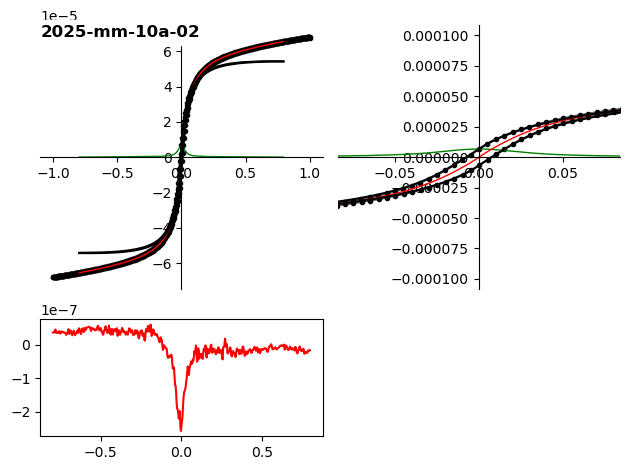

In [8]:
# This is where we process the data in the irm-dcd and dcd files.
# It takes A WHILE...
# Don't worry about the red warnings.

file_skip=[] # If there are any data files you want to skip, add the names of the files to this list. 

# Iterate through each row of the list of specimens...
for ix,row in specimens.iterrows():
    # First we work on the IRM/DC demagnetization data
    file_path = vsm_folder / row['irmdcd_file']
    print('Working on {}\n{}\n'.format(row['subsample'],file_path))
    to_add=row.copy()   # All of the metadata for each sample we're not skipping gets copied over...
    if (row['irmdcd_file'] in file_skip):  # If we're skipping the IRM/DCD file, just output a message
        print('>> Skipping... {}\n'.format(row['irmdcd_file']))
    if (row['irmdcd_file'] not in file_skip): # If we're not skipping it, let's load and process the data
        print(">> Processing: {}\n".format(row['irmdcd_file']))
        s,d = ht.read_dcd(file_path) # Read in the DC demagnetization data
        print(">> IRM/Backfield file read with {} data points.".format(d.shape[0]))
        result_dcd = ht.process_dcd(s,d) # Process DC demagnetization results: the main point here is to 
                                         # find where the DC demagnetization curve crosses M=0 (horizontal axis). 
                                         # That point is the coercivity of remanence (Hcr).
        to_add['Hcr']=float(result_dcd['Hcr']) # Copy the Hcr value to the set of data to be added to our data frame
                                               # Note: the "float" here makes sure we save a decimal number, not an integer 
                                               # or a string of characters (or a list).
        print(">> Backfield processed.")
        if sum(d['type']=='irm')>0:     # If we read in any IRM data...   
            result_irm = ht.process_irm(s,d) # Process IRM data. Here we get the smoothed field, IRM, and 
                                             # gradient (i.e. coercivity spectrum) datasets (some of which we will save later), 
                                             # as well as values for saturation IRM (SIRM) and some IRMs at other key field 
                                             # values that people sometimes like to compare. 
                                             # We're just going to save the field, IRM, and gradient data, SIRM, and the peak value 
                                             # of the second derivative of the IRM, which shows how "spiky" the coercivity spectrum is.
                                             # If that is too spiky, our data might be too noisy to use.
            irm_add=to_add.append(pd.Series(result_irm['irm_derivative'].to_dict()))
            max_d2=np.max(np.gradient(pd.Series(irm_add['gradient']).values,pd.Series(irm_add['field']).values))
            print(">> Max IRM second derivative: {}".format(max_d2))
            to_add['max_d2']=max_d2 # Maximum of second derivative of the IRM
            to_add['SIRM']=float(result_irm['SIRM'])/row['mass'] # Saturation IRM, normalized by mass

            # The following saves the IRM field (in mT) and magnetization data (in Am^2/kg) as a file 
            hm_file = f'{to_add.subsample}-{ix}.hm'
            print (f'>> Saving {hm_file}.')
            H=1000.*np.array(list(irm_add['field'].values())) # Convert field to millitesla
            M=float(to_add['SIRM'])*np.array(list(irm_add['remanence'].values())) # Convert magnetization to Am^2/kg 
            hm_data=pd.DataFrame(zip(H,M)) # Put both H and M together in a data frame
            hm_data.to_csv(processed_folder/hm_file,header=['B','M'],index=False) # Save data frame as a csv file 
                                                                                  # for use with MaxUnmix (Maxbauer et al. 2016)
            
        # Next we work on the hysteresis data
        file_path = vsm_folder / row['hysu_file']
        print('Working on {}\n{}\n'.format(row['subsample'],file_path))
        if (row['hysu_file'] in file_skip): # If we're skipping the hysteresis file, just output a message
            print('>> Skipping... {}\n'.format(row['hysu_file']))
        if (row['hysu_file'] not in file_skip): # If we're not skipping it, let's load and process the data
            s,d=ht.read_hyst(file_path) # Read in the data from the .hysu file
            print(">> Hysteresis file read with {} data points.".format(d['moment'].shape[0]))
            result=ht.process_hyst(s,d,Hgrid=Hgrid) # Process the data. This involves making the loop symmetrical, forcing 
                                                    # it to close (i.e. correcting for magnet or sample drift), smoothing it,
                                                    # correcting for the high-field (paramagnetic) slope, calculating the 
                                                    # reversible and irreversible components of the loop, and finding parameters
                                                    # like Mrs, Ms, Hc, Xhf, Xinit, Q, etc. All of this is described in Jackson 
                                                    # and Solheid (2009).
            print(">> Hysteresis file processed.")
            # The following lines create and save the hysteresis loop graphics 
            fig=plt.figure(1) # Create a new blank space for drawing a figure
            ax_tuple=ht.plot_hyst_report(result,fig,row['subsample']) 
                                                          # plot_hyst_report is in hysttools - it's what draws the loop
                                                          # based on the data we got from processing the loop
            plt.savefig(image_folder/'{}_hystreport.svg'.format(row['subsample']),dpi=300) # Save graphics as SVG (editable)
            plt.savefig(image_folder/'{}_hystreport.png'.format(row['subsample']),dpi=300) # Save graphics as PNG (easy to display)
            # The following assembles the key hysteresis parameters we want to save based on the processed loop
            # Mrs, Ms, Xinit, and Xhf are in mass-normalized units
            to_add=to_add.append(pd.Series({'Mrs':float(result['Mrs'])/row['mass'],
                                            'Ms':float(result['Ms'])/row['mass'],
                                            'Hc':float(result['Hc']),
                                            'Xinit':float(result['Xinit'])/row['mass'],
                                            'Xhf':float(result['Xhf'])/row['mass'],
                                            'Q':float(result['Q']),
                                            'Qeff':float(result['Qeff'])}))
            # I'm not sure we'll use the following immediately, but if you ever want to use the reversible and irreversible 
            # loops for anything, uncomment these lines and save these data somewhere
            #hyst_rh=pd.Series(dict(zip(["{}".format(x) for x in result['reversible']['field']],result['reversible']['moment'])))
            #hyst_ih=pd.Series(dict(zip(["{}".format(x) for x in result['irreversible']['field']],result['irreversible']['moment'])))
            
        # All done! Let's add the data we just loaded/processed to the data frame with all of the results.
        hyst_stats=hyst_stats.append(to_add,ignore_index=True)
        print("IRM/DCD/Hysteresis data processed.")
    

### Some basic calculations required for most plots

In [17]:
# Ratios useful for magnetic grain size analysis
hyst_stats['MrsMs']=hyst_stats['Mrs']/hyst_stats['Ms']
hyst_stats['HcrHc']=hyst_stats['Hcr']/hyst_stats['Hc']

In [18]:
display(hyst_stats) # Show all of the stats we just calculated
hyst_stats.to_csv(processed_folder/'hyst_stats.csv') # Save it all as a csv file (can open in Excel)

,irmdcd_file,hysu_file,subsample,sample,site,season,year,sample_type,watershed,unit,...,Hc,Mrs,Ms,Q,Qeff,SIRM,Xhf,Xinit,MrsMs,HcrHc
0,2022CB0101.irmdcd,2022CB0101.hysu,2022-cb-01-01,2022-cb-01,cb01,NaN,2022.0,marine,bay,NaN,...,0.003467,0.000045,0.000389,4.973489,4.713144,0.000035,6.315236e-05,0.003920,0.115217,1.691937
1,2022CB0103.irmdcd,2022CB0103.hysu,2022-cb-01-03,2022-cb-01,cb01,NaN,2022.0,marine,bay,NaN,...,0.004387,0.000040,0.000370,4.556926,4.242220,0.000028,6.685977e-05,0.003795,0.109334,0.950098
2,2022EG0102.irmdcd,2022EG0102.hysu,2022-eg-01-02,2022-eg-01,eg01,su,2022.0,headwaters,white,NaN,...,0.006678,0.000067,0.000544,4.613937,4.274568,0.000055,1.011770e-04,0.006732,0.123643,2.175777
3,2022EG0103-2.irmdcd,2022EG0103.hysu,2022-eg-01-03,2022-eg-01,eg01,su,2022.0,headwaters,white,NaN,...,0.007153,0.000077,0.000618,4.253647,4.329579,0.000063,1.318311e-04,0.008412,0.124852,1.926282
4,2022EG0103.irmdcd,2022EG0103.hysu,2022-eg-01-03,2022-eg-01,eg01,su,2022.0,headwaters,white,NaN,...,0.007153,0.000077,0.000618,4.253647,4.329579,0.000063,1.318311e-04,0.008412,0.124852,1.402815
5,2022eg0203.irmdcd,2022eg0203.hysu,2022-eg-02-03,2022-eg-02,eg01,su,2022.0,headwaters,white,NaN,...,0.007160,0.000063,0.000648,4.535558,4.341529,0.000053,7.697629e-05,0.007769,0.096973,1.111773
6,2023PR01_bed_sediment.irmdcd,2023PR01_bed_sediment.hysu,2023-pr-01-bed,2023-pr-01-bed,pr01,NaN,2023.0,bed,puyallup,NaN,...,0.007944,0.000043,0.000295,5.214535,5.011629,0.000035,5.105358e-05,0.002565,0.145544,1.607536
7,2023PR01_suspended_silt.irmdcd,2023PR01_suspended_silt.hysu,2023-pr-01-suspended,2023-pr-01-suspended,pr01,NaN,2023.0,suspended,puyallup,NaN,...,0.010629,0.000007,0.000044,5.432576,5.136165,0.000007,1.021153e-07,0.000470,0.167937,3.324013
8,2023PR02_bed_sediment.irmdcd,2023PR02_bed_sediment.hysu,2023-pr-02-bed,2023-pr-02-bed,pr02,NaN,2023.0,bed,puyallup,NaN,...,0.009674,0.000048,0.000301,5.753459,5.584026,0.000045,5.212940e-05,0.003305,0.159573,2.955782
9,2024-cr-20b.irmdcd,2024-cr-20b.hysu,2024-cr-20b,2024-cr-20,cr01,wi,2025.0,suspended,carbon,NaN,...,0.009248,0.000077,0.000561,6.782279,6.029819,0.000075,8.056774e-05,0.004716,0.138059,3.871338


## Plot Data

In [13]:
# Here's how easy it is to plot the hysteresis results now: we're going to make a boxplot showing how Ms varies with 
# watershed, season, and between bed and suspended sediment. "alt" refers to the Altair plotting package. 
P=alt.Chart(hyst_stats).mark_boxplot().encode(
    alt.X('watershed:N'),
    alt.Y('Ms:Q'),
    alt.Color('sample_type:N'),
    alt.Column('season:N')
)
display(P)

alt.Chart(...)

In [23]:
# And here's how to plot a Day et al. (1977) chart with mixing lines from Dunlop (2002)
# It's interactive! Move your mouse over the samples to see the sample ID
day_chart=alt.Chart(hyst_stats).mark_circle().encode(
    alt.X('HcrHc:Q',scale=alt.Scale(type='log'),title='Hcr/Hc'),
    alt.Y('MrsMs:Q',scale=alt.Scale(type='log'),title='Mrs/Ms'),
    alt.Color('sample_type:N'),
    tooltip='sample:N'
).properties(
    width=300,
    height=300
)


day_sdmd1=alt.Chart(ht.dunlop_SDMD1).mark_line(color='lightgray').encode(
    x=alt.X('HcrHc:Q',scale=alt.Scale(type='log'),title='Hcr/Hc'),
    y=alt.Y('MrMs:Q',scale=alt.Scale(type='log'),title='Mrs/Ms')
)

day_sdmd2=alt.Chart(ht.dunlop_SDMD2).mark_line(color='lightgray').encode(
    x=alt.X('HcrHc:Q',scale=alt.Scale(type='log'),title='Hcr/Hc'),
    y=alt.Y('MrMs:Q',scale=alt.Scale(type='log'),title='Mrs/Ms')
)

day_sp10sd=alt.Chart(ht.dunlop_SP10SD).mark_line(color='lightgray').encode(
    x=alt.X('HcrHc:Q',scale=alt.Scale(type='log'),title='Hcr/Hc'),
    y=alt.Y('MrMs:Q',scale=alt.Scale(type='log'),title='Mrs/Ms')
)

day_sp15sd=alt.Chart(ht.dunlop_SP15SD).mark_line(color='lightgray').encode(
    x=alt.X('HcrHc:Q',scale=alt.Scale(type='log'),title='Hcr/Hc'),
    y=alt.Y('MrMs:Q',scale=alt.Scale(type='log'),title='Mrs/Ms')
)

display((day_chart+day_sdmd1+day_sdmd2+day_sp10sd+day_sp15sd))

alt.LayerChart(...)